# Dwarf Example 08: HI Mass Distribution

**EPS Research — Dwarf/Irregular HI Corpus v1.0**

HI mass (log M_HI) distribution across the dwarf corpus.
Dwarfs are gas-dominated — HI mass often exceeds stellar mass.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20320362  
**Sources:** LVHIS (Koribalski 2019), VLA-ANGST (Ott 2012), LITTLE THINGS (Oh 2015), WALLABY DR2  
**Dependencies:** Python 3, numpy, matplotlib

Galaxies with HI mass: 33
log M_HI range: 6.99 -- 9.96 Msun


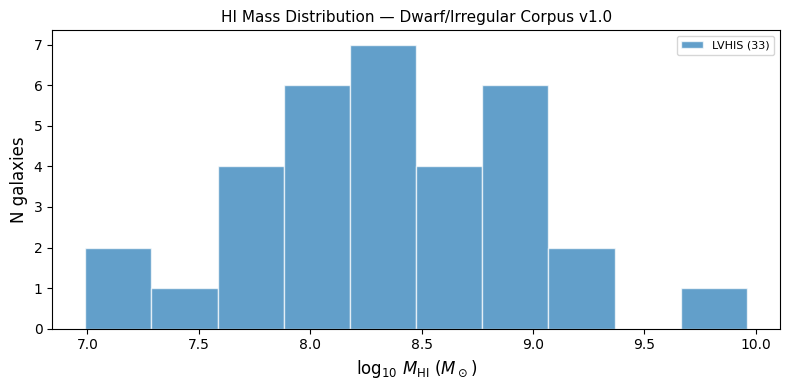

In [1]:
import csv, numpy as np, matplotlib.pyplot as plt
rows=[]
with open('dwarf_irregular_corpus_v1_flat.csv') as f:
    for r in csv.DictReader(f):
        if r.get('mhi_log_msun') and r['mhi_log_msun']:
            rows.append(r)
mhi=[float(r['mhi_log_msun']) for r in rows]
surveys=list(set(r['survey'] for r in rows))
COLORS={'LVHIS':'#1f77b4','VLA-ANGST':'#ff7f0e','LITTLE_THINGS':'#2ca02c','WALLABY':'#d62728'}
print(f"Galaxies with HI mass: {len(rows)}")
print(f"log M_HI range: {min(mhi):.2f} -- {max(mhi):.2f} Msun")
fig,ax=plt.subplots(figsize=(8,4))
for s in surveys:
    vals=[float(r['mhi_log_msun']) for r in rows if r['survey']==s]
    ax.hist(vals,bins=10,alpha=0.7,color=COLORS.get(s,'gray'),label=f'{s} ({len(vals)})',edgecolor='white')
ax.set_xlabel(r'log$_{10}$ $M_{\rm HI}$ ($M_\odot$)',fontsize=12)
ax.set_ylabel('N galaxies',fontsize=12)
ax.set_title('HI Mass Distribution — Dwarf/Irregular Corpus v1.0',fontsize=11)
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig('dw08_hi_mass.png',dpi=150,bbox_inches='tight'); plt.show()